# Week 4 Day 4

## Correlation & Covariance

This notebook analyzes relationships between five Indian stocks using Pearson correlation and covariance.

Objectives:

1. Compute daily returns.
2. Build correlation matrix.
3. Visualize correlation heatmap.
4. Identify most and least correlated stock pairs.
5. Discuss diversification implications.

In [ ]:
import pandas as pd 
import numpy as np 

import yfinance as yf

import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
stocks = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS"
]

data = yf.download(
    stocks,
    period="5y",
    auto_adjust=True
)

[*********************100%***********************]  5 of 5 completed


In [5]:
close_prices = data["Close"]

close_prices.head()

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2021-06-18,700.815247,609.715027,1309.333008,1008.036682,2873.793701
2021-06-21,705.030151,610.537170,1306.719971,1013.290527,2852.701416
2021-06-22,702.709595,610.150330,1316.779785,1008.082031,2877.191895
2021-06-23,703.514771,604.202148,1309.202271,998.842590,2842.503662
2021-06-24,713.341675,613.245239,1358.020264,975.358704,2940.292969


## Daily Returns

Daily returns measure the percentage change in stock prices.

In [6]:
returns = close_prices.pct_change().dropna()

returns.head()

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2021-06-21,0.006014,0.001348,-0.001996,0.005212,-0.007340
2021-06-22,-0.003291,-0.000634,0.007699,-0.005140,0.008585
2021-06-23,0.001146,-0.009749,-0.005755,-0.009165,-0.012056
2021-06-24,0.013968,0.014967,0.037288,-0.023511,0.034403
2021-06-25,0.005875,0.023579,0.009620,-0.022777,0.002134


In [7]:
corr_matrix = returns.corr()

corr_matrix

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Ticker,,,,,
HDFCBANK.NS,1.000000,0.502644,0.247108,0.358635,0.231785
ICICIBANK.NS,0.502644,1.000000,0.231698,0.334980,0.206892
INFY.NS,0.247108,0.231698,1.000000,0.259022,0.727478
RELIANCE.NS,0.358635,0.334980,0.259022,1.000000,0.275214
TCS.NS,0.231785,0.206892,0.727478,0.275214,1.000000


In [8]:
cov_matrix = returns.cov()

cov_matrix

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Ticker,,,,,
HDFCBANK.NS,0.000171,0.000084,0.000051,0.000066,0.000042
ICICIBANK.NS,0.000084,0.000164,0.000047,0.000060,0.000036
INFY.NS,0.000051,0.000047,0.000249,0.000058,0.000157
RELIANCE.NS,0.000066,0.000060,0.000058,0.000198,0.000053
TCS.NS,0.000042,0.000036,0.000157,0.000053,0.000187


## Correlation Heatmap

A heatmap helps visualize relationships between stocks.

Values near:

- +1 → Strong positive correlation
- 0 → No relationship
- -1 → Strong negative correlation

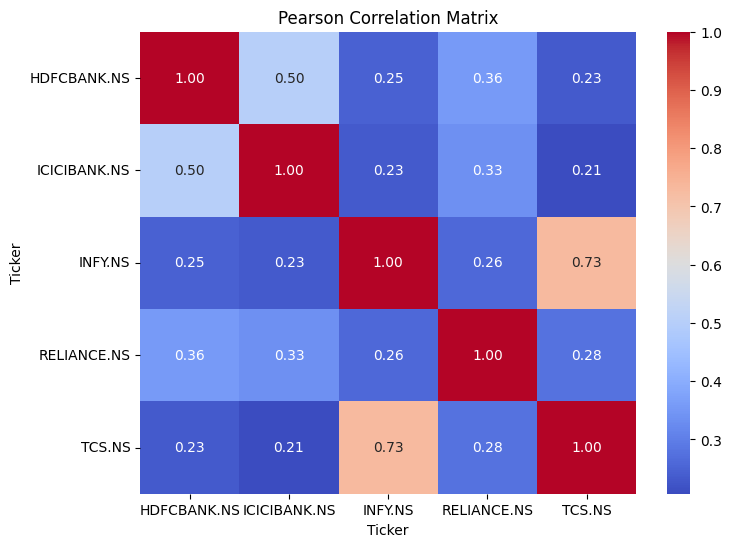

In [9]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Pearson Correlation Matrix"
)

plt.savefig(
    "../images/correlation_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [10]:
corr_pairs = corr_matrix.unstack()

corr_pairs = corr_pairs[
    corr_pairs != 1
]

most_corr = corr_pairs.idxmax()

most_corr_value = corr_pairs.max()

print("Most Correlated Pair:")
print(most_corr)

print("Correlation:")
print(round(most_corr_value, 2))

Most Correlated Pair:
('INFY.NS', 'TCS.NS')
Correlation:
0.73


In [11]:
least_corr = corr_pairs.idxmin()

least_corr_value = corr_pairs.min()

print("Least Correlated Pair:")
print(least_corr)

print("Correlation:")
print(round(least_corr_value, 2))

Least Correlated Pair:
('ICICIBANK.NS', 'TCS.NS')
Correlation:
0.21


# Diversification Commentary

The correlation matrix shows how closely the selected stocks move together.

The most correlated pair tends to move in a similar direction, which reduces diversification benefits because both stocks may react similarly to market events.

The least correlated pair provides better diversification because their price movements are less related. Holding stocks with lower correlations can reduce portfolio risk and improve risk-adjusted returns.

Overall, combining stocks from different sectors is generally more effective for diversification than holding highly correlated stocks from similar industries.